In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_core.tools import Tool

from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

c:\Users\HarshMistry\training-crest\09 Agentic AI\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [2]:
load_dotenv(override=True)

True

# Asynchronus LangGraph

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


In [4]:
def push(text: str):
    """Mock push notification"""
    print("PUSH NOTIFICATION:", text)
    return "Notification sent (mock)"

tool_push = Tool(
    name ="send_push_notification",
    func=push,
    description="usefull for when you want to send a push notification"
)

tool_push.invoke("Hello, me")

PUSH NOTIFICATION: Hello, me


'Notification sent (mock)'

In [5]:
import nest_asyncio
nest_asyncio.apply()

In [8]:
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser

async_browser = create_async_playwright_browser(headless=False)
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [10]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\HarshMistry\AppData\Local\ms-playwright\chromium-1208\chrome-win64\chrome.exe> version=145.0.7632.6>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\HarshMistry\AppData\Local\ms-playwright\chromium-1208\chrome-win64\chrome.exe> version=145.0.7632.6>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\HarshMistry\AppData\Local\ms-playwright\chromium-1208\chrome-win64\chrome.exe> version=145.0.7632.6>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\HarshMistry\AppData\Local\ms-playwright\chromium-1208\chrome-win64\chrome.exe> version=145.0.7632.6>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\HarshMistry\AppData\Local\ms-playwright\chromium-1208\chrome-win64\chrome.exe> version=145.0.7632.6>
get_elements=as

In [19]:
tool_dict = {tool.name:tool for tool in tools}
navigate_tool = tool_dict.get("navigate_browser")
extract_text_tool = tool_dict.get("extract_text")

await navigate_tool.arun({"url":"https://www.cnn.com","timeout": 60000})
text = await extract_text_tool.arun({})

In [20]:
import textwrap
print(textwrap.fill(text))

Breaking News, Latest News and Videos | CNN CNN values your feedback
1. How relevant is this ad to you? 2. Did you encounter any technical
issues? No Video player was slow to load content Video content never
loaded Ad froze or did not finish loading Video content did not start
after ad Audio on ad was too loud Other issues Ad never loaded Ad
prevented/slowed the page from loading Content moved around while ad
loaded Ad was repetitive to ads I've seen previously Other issues
Cancel Submit Thank You! Your effort and contribution in providing
this feedback is much
appreciated. Close Ad Feedback Close icon US World Politics Business
Health Entertainment Style Travel Sports Science Climate Weather
Ukraine-Russia War Israel-Hamas War Games More US World Politics
Business Health Entertainment Style Travel Sports Science Climate
Weather Ukraine-Russia War Israel-Hamas War Games Watch Listen Live TV
Subscribe Sign in My Account Settings Newsletters Topics you follow
Sign out Your CNN account Si

In [21]:
all_tools= tools + [tool_push]

In [26]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")  
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

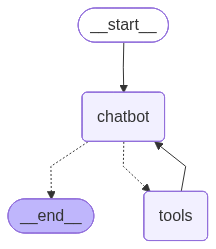

In [34]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=all_tools))
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
config = {"configurable": {"thread_id": "10"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "c:\Users\HarshMistry\training-crest\09 Agentic AI\.venv\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "c:\Users\HarshMistry\training-crest\09 Agentic AI\.venv\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "c:\Users\HarshMistry\training-crest\09 Agentic AI\.venv\Lib\site-packages\gradio\blocks.py", line 2158, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "c:\Users\HarshMistry\training-crest\09 Agentic AI\.venv\Lib\site-packages\gradio\blocks.py", line 1632, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^